In [1]:
import numpy as np
from pathlib import Path
import os, json, sys
import matplotlib.pyplot as plt
cwd = Path.cwd()
import seaborn as sns

from groupBMC.groupBMC import GroupBMC

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [2]:
os.getcwd()

'/srv/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder'

Active late
Protected exceedance probabilities: [3.19781873e-04 1.41172241e-02 9.85562994e-01]
Pairwise permutation p-values (raw): {'Linear vs Gain Fixed': 9.999000099990002e-05, 'Linear vs Gain Modulated': 9.999000099990002e-05, 'Gain Fixed vs Gain Modulated': 0.1347865213478652}
Pairwise permutation p-values (Holm-corrected): {'Linear vs Gain Fixed': np.float64(0.00029997000299970003), 'Linear vs Gain Modulated': np.float64(0.00029997000299970003), 'Gain Fixed vs Gain Modulated': np.float64(0.1347865213478652)}


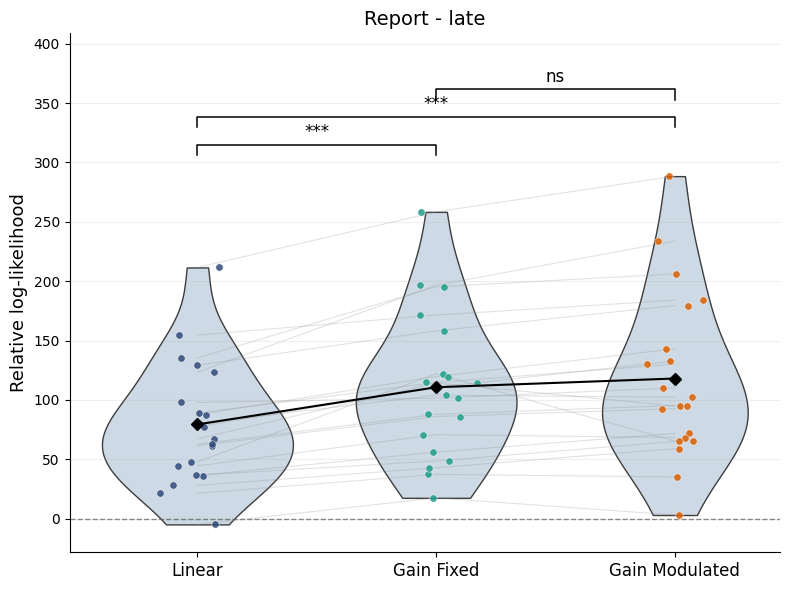

Active early
Protected exceedance probabilities: [0.00282437 0.92833842 0.06883721]
Pairwise permutation p-values (raw): {'Linear vs Gain Fixed': 0.00019998000199980003, 'Linear vs Gain Modulated': 0.00019998000199980003, 'Gain Fixed vs Gain Modulated': 0.0413958604139586}
Pairwise permutation p-values (Holm-corrected): {'Linear vs Gain Fixed': np.float64(0.0005999400059994001), 'Linear vs Gain Modulated': np.float64(0.0005999400059994001), 'Gain Fixed vs Gain Modulated': np.float64(0.0413958604139586)}


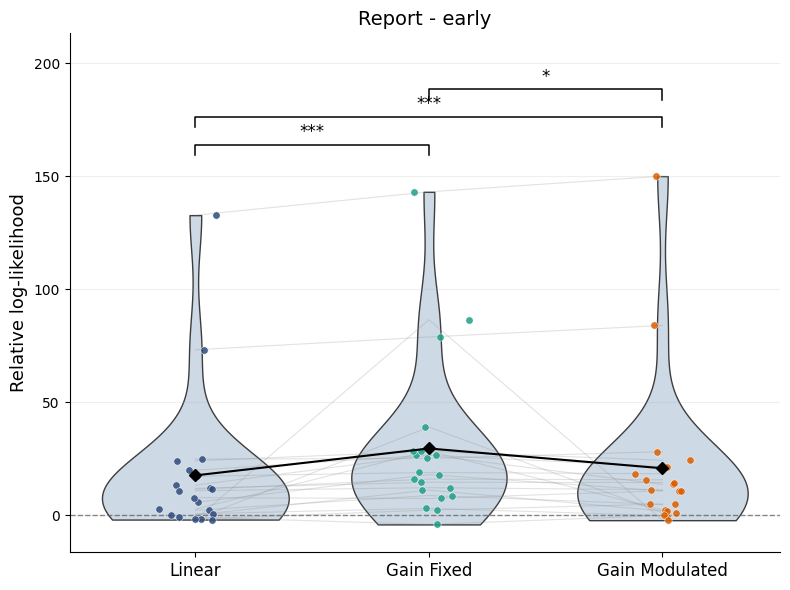

Passive late
Protected exceedance probabilities: [3.32426735e-04 1.53019772e-02 9.84365596e-01]
Pairwise permutation p-values (raw): {'Linear vs Gain Fixed': 9.999000099990002e-05, 'Linear vs Gain Modulated': 9.999000099990002e-05, 'Gain Fixed vs Gain Modulated': 0.049095090490950906}
Pairwise permutation p-values (Holm-corrected): {'Linear vs Gain Fixed': np.float64(0.00029997000299970003), 'Linear vs Gain Modulated': np.float64(0.00029997000299970003), 'Gain Fixed vs Gain Modulated': np.float64(0.049095090490950906)}


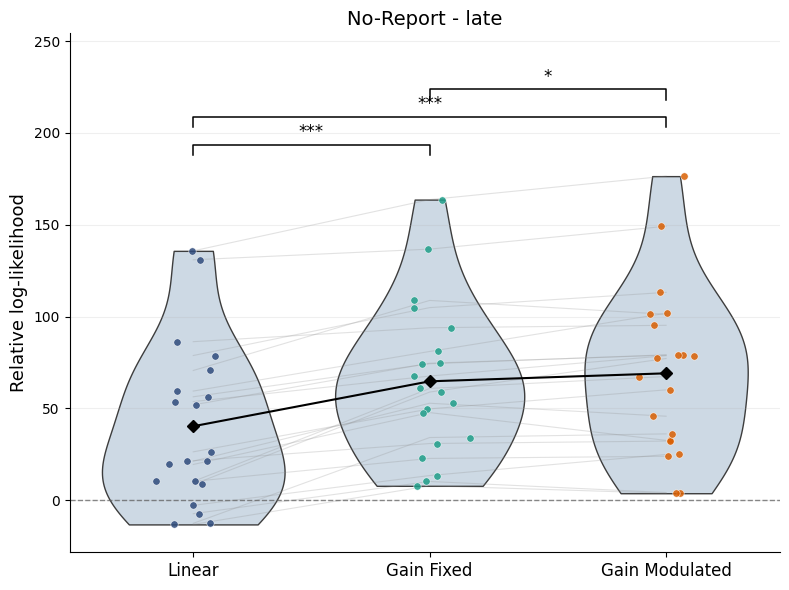

Passive early
Protected exceedance probabilities: [0.00484842 0.98783414 0.00731744]
Pairwise permutation p-values (raw): {'Linear vs Gain Fixed': 0.000999900009999, 'Linear vs Gain Modulated': 0.1126887311268873, 'Gain Fixed vs Gain Modulated': 0.006299370062993701}
Pairwise permutation p-values (Holm-corrected): {'Linear vs Gain Fixed': np.float64(0.0029997000299970002), 'Linear vs Gain Modulated': np.float64(0.1126887311268873), 'Gain Fixed vs Gain Modulated': np.float64(0.012598740125987402)}


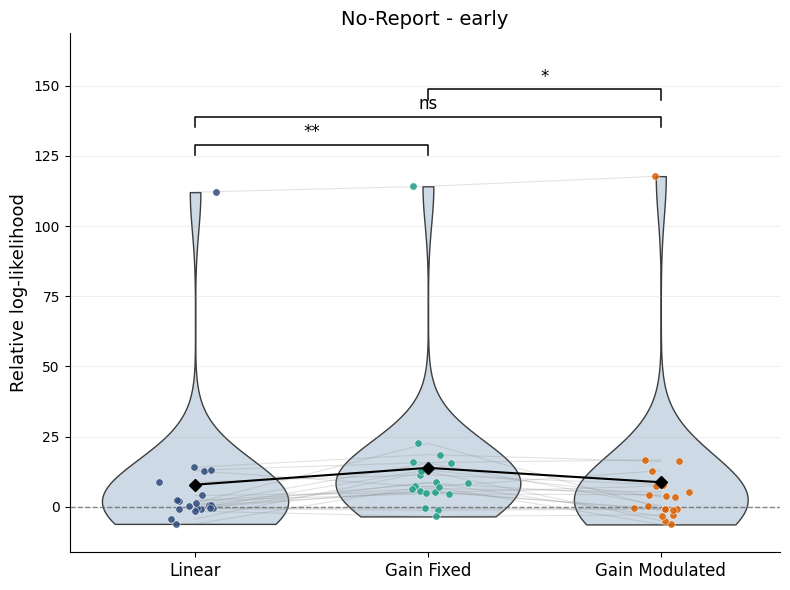

In [3]:
from scipy.stats import rankdata, wilcoxon

checkpoints = [('Active', 'late', f'5CV_Active_late.json'),
               ('Active', 'early', f'5CV_Active_early.json'),
               ('Passive', 'late', f'5CV_Passive_late.json'),
               ('Passive', 'early', f'5CV_Passive_early.json')]


def transform_ll(values, scale):
    if scale == 'raw':
        return values
    if scale == 'exp':
        return np.exp(values)
    raise ValueError("plot_scale must be either 'raw' or 'exp'.")


def paired_permutation_test(x, y, n_permutations=10000, seed=42, statistic='mean'):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    diff = x - y
    if np.allclose(diff, 0.0):
        return 1.0

    if statistic == 'mean':
        stat_values = diff
        observed = np.mean(stat_values)
    elif statistic == 'rank':
        nonzero = ~np.isclose(diff, 0.0)
        stat_values = diff[nonzero]
        if stat_values.size == 0:
            return 1.0
        ranks = np.asarray(rankdata(np.abs(stat_values), method='average'), dtype=float)
        stat_values = np.sign(stat_values) * ranks
        observed = np.mean(stat_values)
    else:
        raise ValueError("comparison_statistic must be either 'mean' or 'rank'.")

    rng = np.random.default_rng(seed)
    permuted = np.empty(n_permutations, dtype=float)
    for i in range(n_permutations):
        signs = rng.choice([-1.0, 1.0], size=stat_values.size)
        permuted[i] = np.mean(stat_values * signs)
    p = (np.sum(np.abs(permuted) >= abs(observed)) + 1.0) / (n_permutations + 1.0)
    return float(p)


def paired_wilcoxon_test(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    diff = x - y
    if np.allclose(diff, 0.0):
        return 1.0
    _, p = wilcoxon(x, y, zero_method='wilcox', alternative='two-sided')
    return float(p)


def max_t_permutation_correction(x_arrays, pair_defs, n_permutations=10000, seed=42, statistic='mean'):
    x_arrays = [np.asarray(vals, dtype=float) for vals in x_arrays]
    diffs = [x_arrays[i] - x_arrays[j] for i, j in pair_defs]

    if statistic == 'mean':
        stats = [diff for diff in diffs]
        observed = np.array([np.abs(np.mean(diff)) for diff in stats], dtype=float)
    elif statistic == 'rank':
        stats = []
        observed_list = []
        for diff in diffs:
            nonzero = ~np.isclose(diff, 0.0)
            stat_values = diff[nonzero]
            if stat_values.size == 0:
                stats.append(np.array([], dtype=float))
                observed_list.append(0.0)
                continue
            ranks = np.asarray(rankdata(np.abs(stat_values), method='average'), dtype=float)
            signed_ranks = np.sign(stat_values) * ranks
            stats.append(signed_ranks)
            observed_list.append(np.abs(np.mean(signed_ranks)))
        observed = np.asarray(observed_list, dtype=float)
    else:
        raise ValueError("comparison_statistic must be either 'mean' or 'rank'.")

    if all(np.allclose(diff, 0.0) for diff in diffs):
        return np.ones(len(pair_defs), dtype=float)

    rng = np.random.default_rng(seed)
    max_stats = np.empty(n_permutations, dtype=float)
    for idx in range(n_permutations):
        if statistic == 'mean':
            signs = rng.choice([-1.0, 1.0], size=diffs[0].size)
            permuted_stats = [np.abs(np.mean(diff * signs)) for diff in stats]
        else:
            permuted_stats = []
            for signed_ranks in stats:
                if signed_ranks.size == 0:
                    permuted_stats.append(0.0)
                else:
                    signs = rng.choice([-1.0, 1.0], size=signed_ranks.size)
                    permuted_stats.append(np.abs(np.mean(signed_ranks * signs)))
        max_stats[idx] = np.max(permuted_stats)
    adjusted = np.array([(np.sum(max_stats >= stat) + 1.0) / (n_permutations + 1.0) for stat in observed], dtype=float)
    return adjusted


def holm_correction(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = pvals[order]
    corrected_sorted = np.empty(m, dtype=float)
    running_max = 0.0
    for i, p in enumerate(sorted_p):
        adjusted = (m - i) * p
        running_max = max(running_max, adjusted)
        corrected_sorted[i] = min(1.0, running_max)
    corrected = np.empty(m, dtype=float)
    corrected[order] = corrected_sorted
    return corrected


def p_to_stars(p):
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


comparison_statistic = 'mean'  # use 'mean', 'rank', or 'wilcoxon' for the pairwise comparison.
correction_method = 'holm'  # use 'holm' or 'maxT'; maxT is for permutation-based comparisons.
plot_scale = globals().get('plot_scale', 'delta_from_linear')

for (task, stage, checkpoint_path) in checkpoints:
    print(task, stage)
    
    with open(checkpoint_path, "r") as f:
        checkpoint = json.load(f)
    detailed = checkpoint["detailed"]

    linear_ll, nonlinear_ll, gainmodul_ll = [], [], []
    for detail in detailed:
        linear_ll.append(detail['ll_linear_mean'])
        nonlinear_ll.append(detail['ll_nonlinear_mean'])
        gainmodul_ll.append(detail['ll_gainmod_mean'])

    # same for the null model (to delete once the null and other models are merged in the same json)
    with open(checkpoint_path.replace('.json', '_OnlyNull.json'), "r") as f:
        null_checkpoint = json.load(f)
    null_detailed = null_checkpoint["detailed"]
    null_ll = [detail['ll_null_mean'] for detail in null_detailed]

    linear_ll = np.asarray(linear_ll, dtype=float)
    nonlinear_ll = np.asarray(nonlinear_ll, dtype=float)
    gainmodul_ll = np.asarray(gainmodul_ll, dtype=float)
    null_ll = np.asarray(null_ll, dtype=float)
    L = np.array([linear_ll, nonlinear_ll, gainmodul_ll])

    result = GroupBMC(L).get_result()
    print('Protected exceedance probabilities:', result.protected_exceedance_probability)

    ll_arrays_plot = [linear_ll - null_ll, nonlinear_ll - null_ll, gainmodul_ll - null_ll]
    model_order = ['Linear', 'Gain Fixed', 'Gain Modulated']
    x_positions = np.arange(3)
    pair_defs = [(0, 1), (0, 2), (1, 2)]

    if comparison_statistic == 'wilcoxon':
        if correction_method == 'maxT':
            raise ValueError("correction_method='maxT' is not supported with comparison_statistic='wilcoxon'. Use 'holm' instead.")
        raw_pvals = [paired_wilcoxon_test(ll_arrays_plot[i], ll_arrays_plot[j]) for i, j in pair_defs]
        corrected_pvals = holm_correction(raw_pvals)
        print('Pairwise Wilcoxon p-values (raw):', {f'{model_order[i]} vs {model_order[j]}': p for (i, j), p in zip(pair_defs, raw_pvals)})
        print('Pairwise Wilcoxon p-values (Holm-corrected):', {f'{model_order[i]} vs {model_order[j]}': p for (i, j), p in zip(pair_defs, corrected_pvals)})
    elif correction_method == 'holm':
        raw_pvals = [paired_permutation_test(ll_arrays_plot[i], ll_arrays_plot[j], statistic=comparison_statistic) for i, j in pair_defs]
        corrected_pvals = holm_correction(raw_pvals)
        print('Pairwise permutation p-values (raw):', {f'{model_order[i]} vs {model_order[j]}': p for (i, j), p in zip(pair_defs, raw_pvals)})
        print('Pairwise permutation p-values (Holm-corrected):', {f'{model_order[i]} vs {model_order[j]}': p for (i, j), p in zip(pair_defs, corrected_pvals)})
    elif correction_method == 'maxT':
        raw_pvals = [paired_permutation_test(ll_arrays_plot[i], ll_arrays_plot[j], statistic=comparison_statistic) for i, j in pair_defs]
        corrected_pvals = max_t_permutation_correction(ll_arrays_plot, pair_defs, statistic=comparison_statistic)
        print('Pairwise permutation p-values (raw):', {f'{model_order[i]} vs {model_order[j]}': p for (i, j), p in zip(pair_defs, raw_pvals)})
        print('Pairwise permutation p-values (max-T corrected):', {f'{model_order[i]} vs {model_order[j]}': p for (i, j), p in zip(pair_defs, corrected_pvals)})
    else:
        raise ValueError("correction_method must be 'holm' or 'maxT'.")

    fig, ax = plt.subplots(figsize=(8, 6))

    violin_arrays = [np.asarray(v, dtype=float) for v in ll_arrays_plot]
    violin_arrays[0] = violin_arrays[0] + np.linspace(-1e-9, 1e-9, len(violin_arrays[0]))
    sns.violinplot(
        data=violin_arrays,
        inner=None,
        cut=0,
        linewidth=1.0,
        ax=ax,
        color='#c9d9e8'
    )

    baseline = 0.0 if plot_scale == 'delta_from_linear' else 1.0
    ax.axhline(baseline, color='0.35', ls='--', lw=1.0, alpha=0.7)

    for subj_idx in range(len(linear_ll)):
        subj_vals = [ll_arrays_plot[0][subj_idx], ll_arrays_plot[1][subj_idx], ll_arrays_plot[2][subj_idx]]
        ax.plot(x_positions, subj_vals, color='0.55', alpha=0.25, lw=0.8, zorder=1)

    condition_means = [np.mean(vals) for vals in ll_arrays_plot]
    ax.plot(
        x_positions,
        condition_means,
        color='black',
        marker='D',
        markersize=6,
        linewidth=1.5,
        zorder=4
    )

    rng = np.random.default_rng(42)
    jitter = 0.08
    point_colors = ['#2f4b7c', '#1f9e89', '#d95f02'][:len(ll_arrays_plot)]
    for x, vals, c in zip(x_positions, ll_arrays_plot, point_colors):
        xj = x + rng.normal(0.0, jitter, size=len(vals))
        ax.scatter(xj, vals, s=28, alpha=0.85, color=c, edgecolors='white', linewidths=0.4, zorder=3)

    plot_min = np.min(np.concatenate(ll_arrays_plot))
    plot_max = np.max(np.concatenate(ll_arrays_plot))
    if plot_scale == 'delta_from_linear':
        plot_min = min(plot_min, baseline)
        plot_max = max(plot_max, baseline)
    plot_span = max(plot_max - plot_min, 1e-6)
    y_base = plot_max + 0.06 * plot_span
    y_step = 0.08 * plot_span
    h = 0.03 * plot_span

    bracket_specs = [((i, j), p_corr) for (i, j), p_corr in zip(pair_defs, corrected_pvals)]

    for k, ((i, j), p_corr) in enumerate([(spec[0], spec[1]) for spec in bracket_specs]):
        y = y_base + k * y_step
        ax.plot([i, i, j, j], [y, y + h, y + h, y], color='black', lw=1.1, zorder=4)
        ax.text((i + j) / 2, y + h + 0.01 * plot_span, p_to_stars(p_corr), ha='center', va='bottom', fontsize=12)

    y_top = y_base + len(bracket_specs) * y_step + h + 0.08 * plot_span
    ax.set_ylim(plot_min - 0.08 * plot_span, y_top)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(model_order, fontsize=12)
    y_label = 'Relative log-likelihood'
    ax.set_ylabel(y_label, fontsize=13)
    task_names_for_plot = {'Active': 'Report', 'Passive': 'No-Report'}
    ax.set_title(f'{task_names_for_plot[task]} - {stage}', fontsize=14)
    ax.grid(axis='y', alpha=0.2)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig(f'Results_EEG_v3/Population_LL_Comparison_{task}_{stage}_delta_from_null.png', dpi=300)
    plt.show()

In [13]:
import pandas as pd
from statsmodels.stats.anova import AnovaRM

anova_rows = []

for task, stage, checkpoint_path in checkpoints:
    with open(checkpoint_path, 'r') as f:
        checkpoint = json.load(f)
    with open(checkpoint_path.replace('.json', '_OnlyNull.json'), 'r') as f:
        null_checkpoint = json.load(f)

    null_by_subj = {
        detail.get('part', detail.get('participant')): detail['ll_null_mean']
        for detail in null_checkpoint['detailed']
    }

    for detail in checkpoint['detailed']:
        subj = detail.get('part', detail.get('participant'))
        null_mean = null_by_subj.get(subj)
        if null_mean is None:
            raise KeyError(f"Missing null model result for subject {subj} in {checkpoint_path.replace('.json', '_OnlyNull.json')}")

        anova_rows.extend([
            {
                'task': task,
                'period': stage,
                'subj': subj,
                'model': 'Linear',
                'll_delta_null': detail['ll_linear_mean'] - null_mean,
            },
            {
                'task': task,
                'period': stage,
                'subj': subj,
                'model': 'Gain Fixed',
                'll_delta_null': detail['ll_nonlinear_mean'] - null_mean,
            },
            {
                'task': task,
                'period': stage,
                'subj': subj,
                'model': 'Gain Modulated',
                'll_delta_null': detail['ll_gainmod_mean'] - null_mean,
            },
        ])

anova_df = pd.DataFrame(anova_rows)
anova_df['task'] = pd.Categorical(anova_df['task'], categories=['Active', 'Passive'], ordered=True)
anova_df['period'] = pd.Categorical(anova_df['period'], categories=['early', 'late'], ordered=True)
anova_df['model'] = pd.Categorical(anova_df['model'], categories=['Linear', 'Gain Fixed', 'Gain Modulated'], ordered=True)

print('Task x period x model repeated-measures ANOVA on log-likelihood delta from null')
print('Dependent variable: ll_delta_null')
print()

full_cell_counts = {subj: len(df[['task', 'period', 'model']].drop_duplicates()) for subj, df in anova_df.groupby('subj')}
if any(count != 12 for count in full_cell_counts.values()):
    bad_subjects = {subj: count for subj, count in full_cell_counts.items() if count != 12}
    raise ValueError(
        f"The combined task x period x model design is unbalanced; each subject needs 12 cells. Offending subjects: {bad_subjects}"
    )

print(f'Combined analysis: using {anova_df["subj"].nunique()} subjects')
print(AnovaRM(anova_df, depvar='ll_delta_null', subject='subj', within=['task', 'period', 'model']).fit())
print()

for task_name, task_df in anova_df.groupby('task', sort=False, observed=True):
    cell_counts = {subj: len(df[['period', 'model']].drop_duplicates()) for subj, df in task_df.groupby('subj')}
    if any(count != 6 for count in cell_counts.values()):
        bad_subjects = {subj: count for subj, count in cell_counts.items() if count != 6}
        raise ValueError(
            f"{task_name} is unbalanced; each subject needs 6 period x model cells. Offending subjects: {bad_subjects}"
        )

    print(f'{task_name}: using {task_df["subj"].nunique()} subjects')
    print(AnovaRM(task_df, depvar='ll_delta_null', subject='subj', within=['period', 'model']).fit())
    print()


Task x period x model repeated-measures ANOVA on log-likelihood delta from null
Dependent variable: ll_delta_null

Combined analysis: using 20 subjects
                     Anova
                  F Value Num DF  Den DF Pr > F
-----------------------------------------------
task              13.6856 1.0000 19.0000 0.0015
period            64.6741 1.0000 19.0000 0.0000
model             47.2258 2.0000 38.0000 0.0000
task:period        5.8284 1.0000 19.0000 0.0260
task:model         2.2946 2.0000 38.0000 0.1146
period:model      48.9843 2.0000 38.0000 0.0000
task:period:model  0.8992 2.0000 38.0000 0.4154


Active: using 20 subjects
                  Anova
             F Value Num DF  Den DF Pr > F
------------------------------------------
period       51.5437 1.0000 19.0000 0.0000
model        25.4067 2.0000 38.0000 0.0000
period:model 20.6481 2.0000 38.0000 0.0000


Passive: using 20 subjects
                  Anova
             F Value Num DF  Den DF Pr > F
--------------------------